In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def propagate(transition_matrix,n):
    return np.linalg.matrix_power(transition_matrix,n)

In [11]:
V = 20
K = 5
random_map = False
triggers = list(range(K))
outputs = np.sort(np.random.choice(list(range(K,V)), size=K, replace=False)).tolist() if random_map else list(range(K,2*K))
print(f"Triggers: {triggers}")
print(f"Outputs: {outputs}")

stationary = np.ones(V)/(V+K)
stationary[outputs] *= 2

transition_matrix = np.zeros((V,V)) # transition_matrix[i,j] = P(j|i)
transition_matrix[K:,:] = 1/V

for i in range(K):
    transition_matrix[i,outputs[i]] = 1.0


Triggers: [0, 1, 2, 3, 4]
Outputs: [5, 6, 7, 8, 9]


Text(0, 0.5, 'Current State $a$')

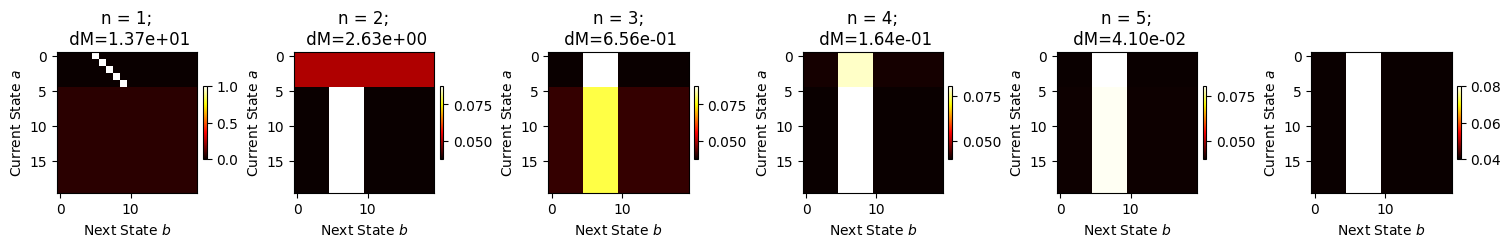

In [12]:
ncols = 5

fig , axes = plt.subplots(ncols=ncols + 1 , figsize=(ncols*3, 3),layout='constrained')
limiting = np.tile(stationary, (V,1))

for n in range(ncols):
    ax = axes[n]
    M = propagate(transition_matrix,n+1)
    im = ax.imshow(M, cmap='hot', interpolation='nearest')#,vmin=0)
    ax.set_xlabel("Next State $b$")
    ax.set_ylabel("Current State $a$")
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.026, pad=0.04)
    ax.set_title(f"n = {n+1};\n dM={np.sum(np.abs(M-limiting)):.2e}")

ax = axes[ncols]
# limiting = stationary for all a

im = ax.imshow(limiting, cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.026, pad=0.04)
ax.set_xlabel("Next State $b$")
ax.set_ylabel("Current State $a$")